# Лабораторная работа №1: Классификация изображений солнечных панелей

Датасет: https://www.kaggle.com/datasets/hemanthsai7/solar-panel-dust-detection

Задача - бинарная классификация изображений: определить, запылена поверхность солнечной панели или нет. Запылённость снижает выработку электроэнергии на 10-30%, поэтому автоматическая детекция помогает планировать обслуживание и сокращать потери.


## Выбор метрик


Классы умеренно сбалансированы, поэтому основной метрикой выбран F1, дополнительно смотрим Accuracy, Precision и Recall.

- Accuracy - общая доля верных предсказаний.
- Precision - из предсказанных запылённых панелей сколько действительно запылённые. Показывает, как часто модель ошибается в сторону ложных тревог.
- Recall - какую долю реально запылённых панелей модель находит. Критична, чтобы не пропустить загрязнение.
- F1-Score - гармоническое среднее precision и recall, устойчивое к перекосу классов.


## Установка зависимостей и загрузка данных


In [ ]:
!pip install -q kagglehub torchmetrics matplotlib seaborn scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.7 MB/s eta 0:00:00


In [ ]:
import kagglehub

DATASET_DOWNLOAD_PATH = kagglehub.dataset_download('hemanthsai7/solar-panel-dust-detection')
print('Path to dataset files:', DATASET_DOWNLOAD_PATH)

Using Colab cache for faster access to the 'solar-panel-dust-detection' dataset.
Path to dataset files: /kaggle/input/solar-panel-dust-detection


## Импорты и конфигурация


In [ ]:
import os
import math
import random
import time
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import ViT_B_16_Weights
from torchmetrics import Accuracy, Precision, Recall, F1Score

from sklearn.metrics import confusion_matrix

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Устройство: cuda
GPU: Tesla T4


## Анализ датасета


In [ ]:
DATA_ROOT = Path(DATASET_DOWNLOAD_PATH)

all_dirs = [d for d in DATA_ROOT.rglob('*') if d.is_dir()]
print('Найденные директории:')
for d in all_dirs:
    imgs = list(d.glob('*.jpg')) + list(d.glob('*.png')) + list(d.glob('*.jpeg'))
    if imgs:
        print(f'  {d}: {len(imgs)} изображений')

Найденные директории:
  /kaggle/input/solar-panel-dust-detection/Detect_solar_dust/Dusty: 1069 изображений
  /kaggle/input/solar-panel-dust-detection/Detect_solar_dust/Clean: 1493 изображений


In [ ]:
def find_dataset_root(root: Path):
    for d in sorted(root.rglob('*')):
        if d.is_dir():
            subdirs = [x for x in d.iterdir() if x.is_dir()]
            if len(subdirs) >= 2:
                imgs = []
                for sd in subdirs:
                    imgs += list(sd.glob('*.jpg')) + list(sd.glob('*.png')) + list(sd.glob('*.jpeg'))
                if len(imgs) > 10:
                    return d
    return root

DATASET_PATH = find_dataset_root(DATA_ROOT)
print(f'Корневая папка датасета: {DATASET_PATH}')

CLASS_NAMES = sorted([d.name for d in DATASET_PATH.iterdir() if d.is_dir()])
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Классы: {CLASS_NAMES}')

class_counts = {}
for cls in CLASS_NAMES:
    imgs = (list((DATASET_PATH / cls).glob('*.jpg')) +
            list((DATASET_PATH / cls).glob('*.png')) +
            list((DATASET_PATH / cls).glob('*.jpeg')))
    class_counts[cls] = len(imgs)
    print(f'  {cls}: {len(imgs)} изображений')

print(f'Всего: {sum(class_counts.values())}')

Корневая папка датасета: /kaggle/input/solar-panel-dust-detection/Detect_solar_dust
Классы: ['Clean', 'Dusty']
  Clean: 1493 изображений
  Dusty: 1069 изображений
Всего: 2562


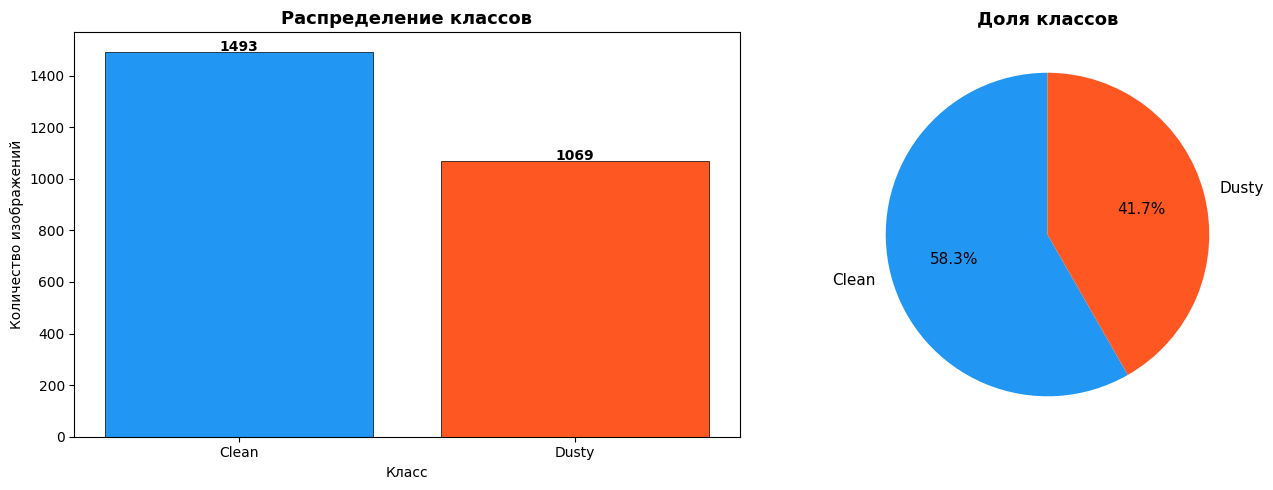

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#FF5722']

axes[0].bar(CLASS_NAMES, class_counts.values(), color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Распределение классов', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Класс'); axes[0].set_ylabel('Количество изображений')
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 2, str(cnt), ha='center', fontweight='bold')

axes[1].pie(class_counts.values(), labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Доля классов', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

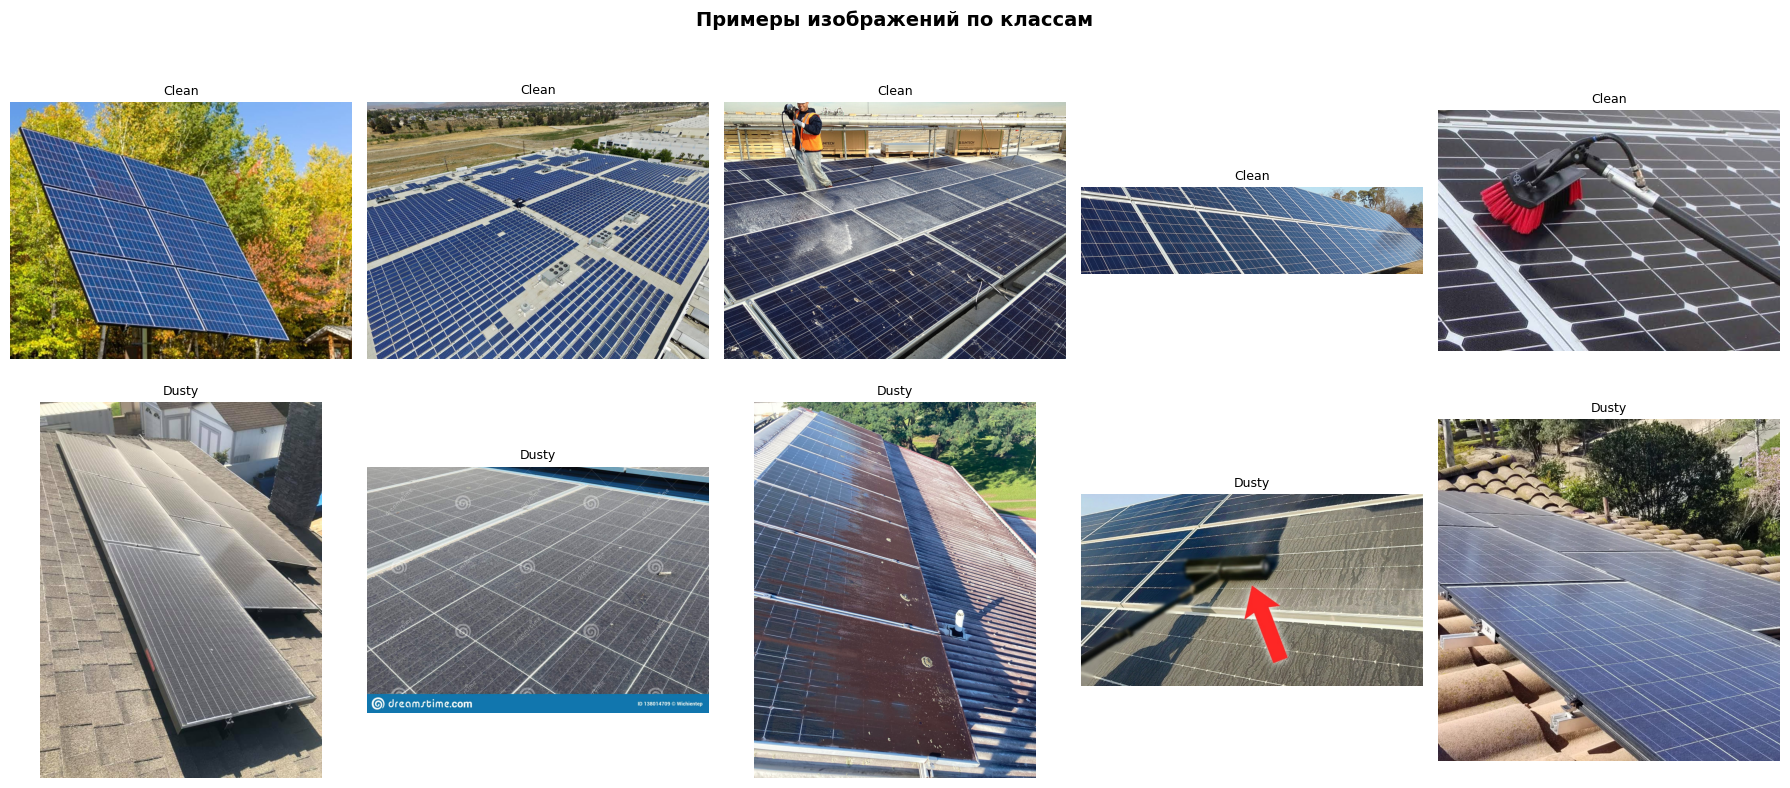

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Примеры изображений по классам', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    cls_path = DATASET_PATH / cls
    imgs = list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.png')) + list(cls_path.glob('*.jpeg'))
    for col, img_path in enumerate(random.sample(imgs, min(5, len(imgs)))):
        axes[row][col].imshow(Image.open(img_path).convert('RGB'))
        axes[row][col].set_title(cls, fontsize=9)
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
widths, heights = [], []
for cls in CLASS_NAMES:
    imgs = list((DATASET_PATH / cls).glob('*.jpg'))[:50]
    for p in imgs:
        w, h = Image.open(p).size
        widths.append(w); heights.append(h)

print(f'Ширина:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}')
print(f'Высота:  min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}')

IMG_SIZE = 224
print(f'\nВыбранный размер для обучения: {IMG_SIZE}x{IMG_SIZE}')

Ширина:  min=259, max=2048, mean=1054
Высота:  min=146, max=2048, mean=977

Выбранный размер для обучения: 224x224


### Трансформации и разбиение на выборки


In [ ]:
baseline_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
def get_dataloaders(transform_train, transform_val=None, batch_size=32,
                    val_split=0.15, test_split=0.15):
    if transform_val is None:
        transform_val = val_transform

    full_ds = datasets.ImageFolder(root=str(DATASET_PATH), transform=transform_train)
    total     = len(full_ds)
    val_size  = int(total * val_split)
    test_size = int(total * test_split)
    train_size = total - val_size - test_size

    g = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = random_split(full_ds, [train_size, val_size, test_size], generator=g)

    val_ds_clean    = datasets.ImageFolder(root=str(DATASET_PATH), transform=transform_val)
    val_ds.dataset  = val_ds_clean
    test_ds.dataset = val_ds_clean

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print(f'Train: {train_size} | Val: {val_size} | Test: {test_size}')
    return train_loader, val_loader, test_loader, full_ds.classes

BATCH_SIZE = 32

train_loader, val_loader, test_loader, CLASS_NAMES = get_dataloaders(
    baseline_transform, val_transform, batch_size=BATCH_SIZE
)
print(f'Классы: {CLASS_NAMES}')

Train: 1794 | Val: 384 | Test: 384
Классы: ['Clean', 'Dusty']


### Утилиты обучения и оценки


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total

def compute_metrics(model, loader, device, num_classes):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            all_preds.append(model(images.to(device)).argmax(1).cpu())
            all_labels.append(labels)
    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    task = 'binary' if num_classes == 2 else 'multiclass'
    avg  = 'macro'
    metrics = {
        'accuracy':  Accuracy (task=task, num_classes=num_classes          )(all_preds, all_labels).item(),
        'precision': Precision(task=task, num_classes=num_classes, average=avg)(all_preds, all_labels).item(),
        'recall':    Recall   (task=task, num_classes=num_classes, average=avg)(all_preds, all_labels).item(),
        'f1':        F1Score  (task=task, num_classes=num_classes, average=avg)(all_preds, all_labels).item(),
    }
    return metrics, all_preds, all_labels

def train_model(model, train_loader, val_loader, num_epochs, lr, device,
                model_name='model', label_smoothing=0.0, weight_decay=1e-4):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_weights = 0.0, None

    print(f'\n{"="*62}')
    print(f'  {model_name}')
    print(f'{"="*62}')
    print(f'{"Эпоха":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>10} | {"Val Acc":>9}')
    print('-' * 62)

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.4f}  | {vl_loss:>10.4f} | {vl_acc:>8.4f}  [{time.time()-t0:.1f}s]')

    print(f'\nЛучший Val Acc: {best_val_acc:.4f}')
    model.load_state_dict(best_weights)
    return model, history

def plot_history(history, title='История обучения', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', markersize=4, label='Train')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', markersize=4, label='Val')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(preds, labels, class_names, title='Матрица ошибок', save_path=None):
    cm = confusion_matrix(labels.numpy(), preds.numpy())
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.ylabel('Истинный класс'); plt.xlabel('Предсказанный класс')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

results_log = {}
print('Утилиты готовы.')

Утилиты готовы.


## Бейзлайн

Используем готовые модели из `torchvision`: свёрточную сеть ResNet-18 и трансформер ViT-B/16. Обе — с предобученными весами ImageNet.


In [ ]:
NUM_EPOCHS_BASELINE = 15
LR_RESNET           = 1e-4
LR_VIT              = 1e-5

### Бейзлайн ResNet-18


In [ ]:
def build_resnet18(num_classes, pretrained=True):
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model   = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model_resnet = build_resnet18(NUM_CLASSES)
print(f'ResNet-18: параметров = {sum(p.numel() for p in model_resnet.parameters()):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]

ResNet-18: параметров = 11,177,538



  ResNet-18 (Бейзлайн)
 Эпоха | Train Loss | Train Acc |   Val Loss |   Val Acc
--------------------------------------------------------------
     1 |     0.4446 |   0.8032  |     0.4007 |   0.8307  [67.5s]
     2 |     0.1565 |   0.9482  |     0.4331 |   0.8255  [61.0s]
     3 |     0.0720 |   0.9788  |     0.4533 |   0.8464  [60.5s]
     4 |     0.0395 |   0.9883  |     0.4948 |   0.8594  [58.1s]
     5 |     0.0275 |   0.9905  |     0.6885 |   0.8099  [59.1s]
     6 |     0.0701 |   0.9777  |     0.5532 |   0.8359  [58.8s]
     7 |     0.0265 |   0.9911  |     0.5591 |   0.8307  [58.9s]
     8 |     0.0295 |   0.9905  |     0.5849 |   0.8281  [59.1s]
     9 |     0.0273 |   0.9933  |     0.5999 |   0.8333  [58.1s]
    10 |     0.0226 |   0.9944  |     0.6071 |   0.8307  [60.1s]
    11 |     0.0203 |   0.9922  |     0.6039 |   0.8464  [59.6s]
    12 |     0.0267 |   0.9894  |     0.6050 |   0.8438  [60.3s]
    13 |     0.0195 |   0.9944  |     0.6234 |   0.8359  [60.7s]
    14 |   

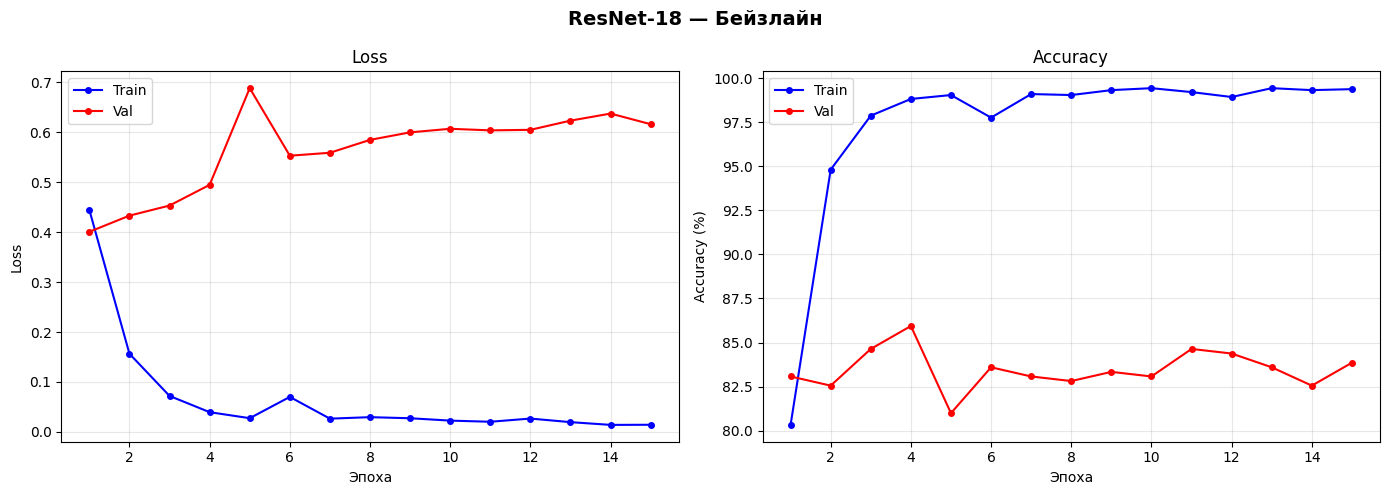

In [ ]:
model_resnet, history_resnet = train_model(
    model_resnet, train_loader, val_loader,
    num_epochs=NUM_EPOCHS_BASELINE, lr=LR_RESNET, device=DEVICE,
    model_name='ResNet-18 (Бейзлайн)'
)
plot_history(history_resnet, 'ResNet-18 — Бейзлайн', 'history_resnet_baseline.png')

Метрики ResNet-18 (бейзлайн):
  accuracy: 0.8776
  precision: 0.9301
  recall: 0.7824
  f1: 0.8498


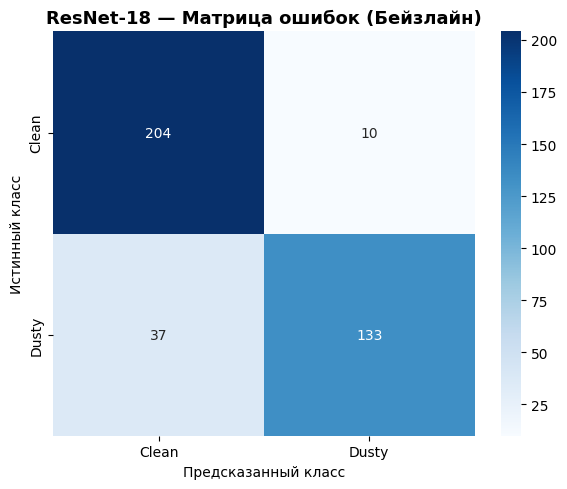

In [ ]:
metrics_resnet, preds_resnet, labels_resnet = compute_metrics(
    model_resnet, test_loader, DEVICE, NUM_CLASSES
)
results_log['Бейзлайн ResNet-18'] = metrics_resnet
print('Метрики ResNet-18 (бейзлайн):')
for k, v in metrics_resnet.items(): print(f'  {k}: {v:.4f}')
plot_confusion_matrix(preds_resnet, labels_resnet, CLASS_NAMES,
                      'ResNet-18 — Матрица ошибок (Бейзлайн)', 'cm_resnet_baseline.png')

### Бейзлайн ViT-B/16


In [ ]:
def build_vit_b16(num_classes, pretrained=True):
    weights = ViT_B_16_Weights.DEFAULT if pretrained else None
    model   = models.vit_b_16(weights=weights)
    model.heads = nn.Linear(model.hidden_dim, num_classes)
    return model

model_vit = build_vit_b16(NUM_CLASSES)
print(f'ViT-B/16: параметров = {sum(p.numel() for p in model_vit.parameters()):,}')

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 74.6MB/s]


ViT-B/16: параметров = 85,800,194



  ViT-B/16 (Бейзлайн)
 Эпоха | Train Loss | Train Acc |   Val Loss |   Val Acc
--------------------------------------------------------------
     1 |     0.5084 |   0.7542  |     0.3733 |   0.8333  [84.5s]
     2 |     0.2832 |   0.8946  |     0.3245 |   0.8490  [85.7s]
     3 |     0.1588 |   0.9470  |     0.3299 |   0.8646  [83.5s]
     4 |     0.1320 |   0.9576  |     0.3376 |   0.8620  [83.8s]
     5 |     0.0539 |   0.9894  |     0.3418 |   0.8750  [83.7s]
     6 |     0.0333 |   0.9916  |     0.3843 |   0.8672  [84.8s]
     7 |     0.0251 |   0.9933  |     0.3928 |   0.8776  [83.1s]
     8 |     0.0191 |   0.9944  |     0.4156 |   0.8724  [83.9s]
     9 |     0.0161 |   0.9933  |     0.4240 |   0.8776  [84.0s]
    10 |     0.0137 |   0.9955  |     0.4465 |   0.8776  [83.2s]
    11 |     0.0131 |   0.9939  |     0.4385 |   0.8750  [83.4s]
    12 |     0.0117 |   0.9933  |     0.4426 |   0.8698  [83.5s]
    13 |     0.0107 |   0.9955  |     0.4468 |   0.8724  [85.2s]
    14 |    

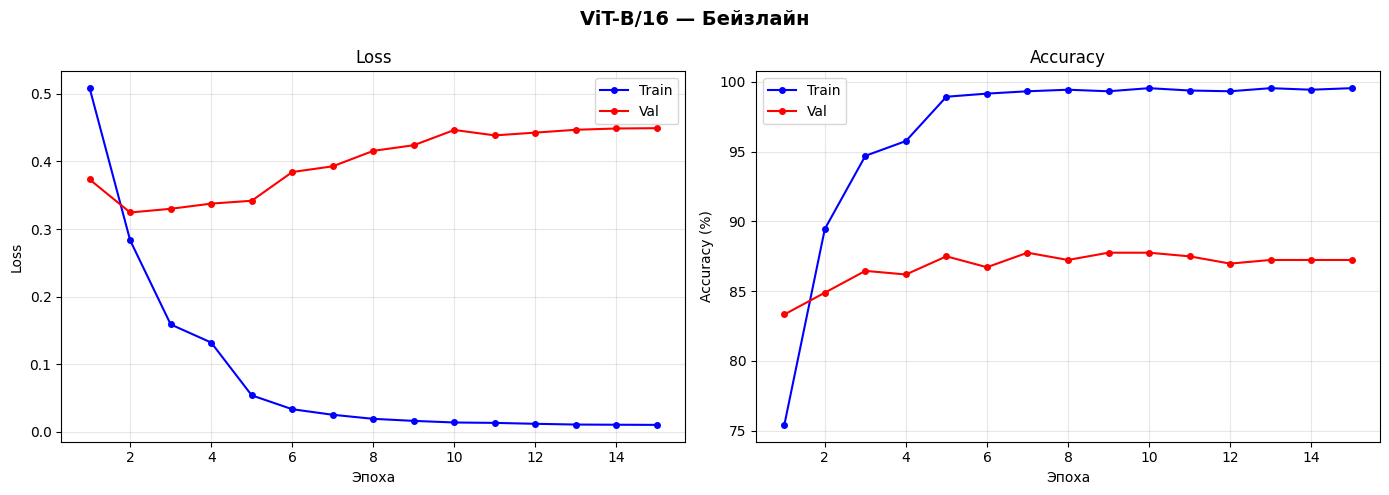

In [ ]:
model_vit, history_vit = train_model(
    model_vit, train_loader, val_loader,
    num_epochs=NUM_EPOCHS_BASELINE, lr=LR_VIT, device=DEVICE,
    model_name='ViT-B/16 (Бейзлайн)'
)
plot_history(history_vit, 'ViT-B/16 — Бейзлайн', 'history_vit_baseline.png')

Метрики ViT-B/16 (бейзлайн):
  accuracy: 0.8880
  precision: 0.8848
  recall: 0.8588
  f1: 0.8716


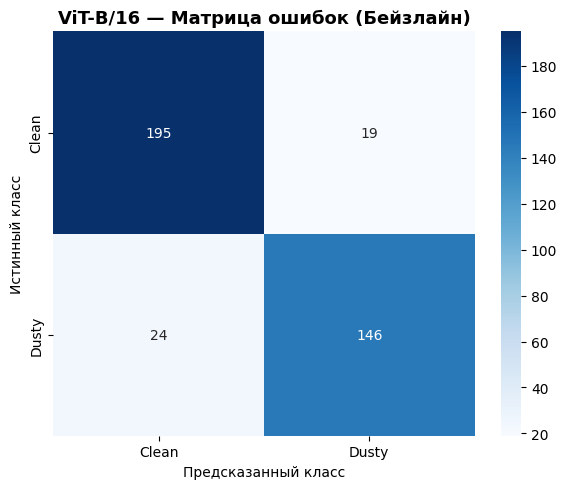

In [ ]:
metrics_vit, preds_vit, labels_vit = compute_metrics(
    model_vit, test_loader, DEVICE, NUM_CLASSES
)
results_log['Бейзлайн ViT-B/16'] = metrics_vit
print('Метрики ViT-B/16 (бейзлайн):')
for k, v in metrics_vit.items(): print(f'  {k}: {v:.4f}')
plot_confusion_matrix(preds_vit, labels_vit, CLASS_NAMES,
                      'ViT-B/16 — Матрица ошибок (Бейзлайн)', 'cm_vit_baseline.png')

### Сравнение бейзлайн-моделей


In [ ]:
df_baseline = pd.DataFrame({
    'бейзлайн модель': list(results_log.keys()),
    'Accuracy':  [v['accuracy']  for v in results_log.values()],
    'Precision': [v['precision'] for v in results_log.values()],
    'Recall':    [v['recall']    for v in results_log.values()],
    'F1-Score':  [v['f1']        for v in results_log.values()],
})
print('\n=== Сравнение бейзлайн-моделей ===')
print(df_baseline.to_string(index=False, float_format='{:.4f}'.format))


=== Сравнение бейзлайн-моделей ===
   бейзлайн модель  Accuracy  Precision  Recall  F1-Score
Бейзлайн ResNet-18    0.8776     0.9301  0.7824    0.8498
 Бейзлайн ViT-B/16    0.8880     0.8848  0.8588    0.8716


### Выводы по бейзлайну

Обе предобученные модели дают близкий результат. ResNet-18: Accuracy 0.8776, F1 0.8498. Precision высокий (0.9301), но Recall 0.7824 - модель почти не путает чистые панели с грязными, зато пропускает около 22% реально запылённых. ViT-B/16 даёт более сбалансированные метрики: Accuracy 0.8880, F1 0.8716, Recall 0.8588. Глобальное внимание лучше ловит пыль, распределённую по всей поверхности панели, поэтому Recall выше.


## Улучшенный бейзлайн

Гипотезы для улучшения:

1. Мягкие аугментации (RandomFlip, Rotation ±10°, лёгкий ColorJitter) добавят вариативности без искажения признаков пыли и должны повысить Recall.
2. Label Smoothing = 0.1 снизит уверенность модели на тренировочных метках и уменьшит переобучение.
3. Увеличенный Weight Decay = 1e-3 даст более сильную L2-регуляризацию.

Ниже проверяем все три гипотезы совместно - обучаем те же модели с аугментированным train'ом и новыми параметрами.


In [ ]:
augmented_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_loader_aug, val_loader_aug, test_loader_aug, _ = get_dataloaders(
    augmented_transform, val_transform, batch_size=BATCH_SIZE
)

NUM_EPOCHS_IMPROVED = 18
print(f'Аугментированные загрузчики готовы.')
print(f'Эпох для улучшенного бейзлайна: {NUM_EPOCHS_IMPROVED}')

Train: 1794 | Val: 384 | Test: 384
Аугментированные загрузчики готовы.
Эпох для улучшенного бейзлайна: 18


### ResNet-18 с улучшениями



  ResNet-18 (Улучшенный)
 Эпоха | Train Loss | Train Acc |   Val Loss |   Val Acc
--------------------------------------------------------------
     1 |     0.5136 |   0.7871  |     0.5878 |   0.7448  [61.6s]
     2 |     0.4177 |   0.8673  |     0.5081 |   0.8359  [61.4s]
     3 |     0.3699 |   0.9013  |     0.4746 |   0.8490  [61.0s]
     4 |     0.3424 |   0.9231  |     0.4995 |   0.8542  [61.3s]
     5 |     0.3231 |   0.9320  |     0.4848 |   0.8177  [61.2s]
     6 |     0.3210 |   0.9331  |     0.4782 |   0.8516  [60.6s]
     7 |     0.3087 |   0.9537  |     0.4727 |   0.8620  [61.7s]
     8 |     0.2853 |   0.9604  |     0.4682 |   0.8698  [61.1s]
     9 |     0.2595 |   0.9760  |     0.4601 |   0.8568  [61.5s]
    10 |     0.2613 |   0.9766  |     0.4842 |   0.8490  [60.3s]
    11 |     0.2571 |   0.9777  |     0.4667 |   0.8490  [64.7s]
    12 |     0.2489 |   0.9844  |     0.4480 |   0.8490  [62.1s]
    13 |     0.2405 |   0.9849  |     0.4673 |   0.8516  [61.9s]
    14 | 

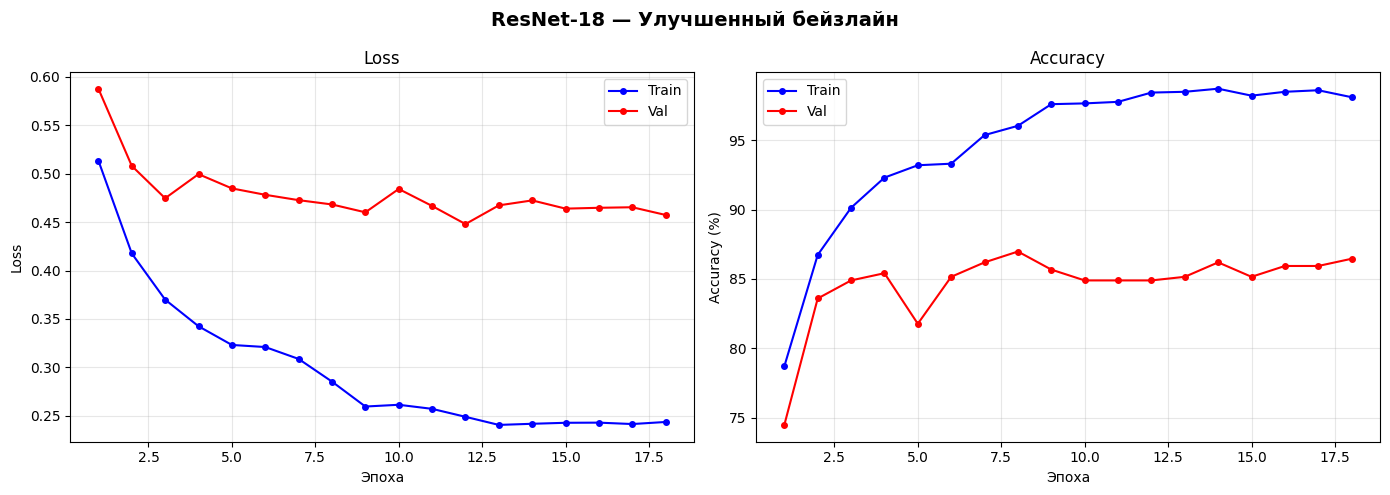

In [ ]:
model_resnet_imp, history_resnet_imp = train_model(
    build_resnet18(NUM_CLASSES),
    train_loader_aug, val_loader_aug,
    num_epochs=NUM_EPOCHS_IMPROVED, lr=LR_RESNET, device=DEVICE,
    model_name='ResNet-18 (Улучшенный)',
    label_smoothing=0.1, weight_decay=1e-3
)
plot_history(history_resnet_imp, 'ResNet-18 — Улучшенный бейзлайн', 'history_resnet_improved.png')

Метрики ResNet-18 (улучшенный):
  accuracy: 0.8828
  precision: 0.8834
  recall: 0.8471
  f1: 0.8649


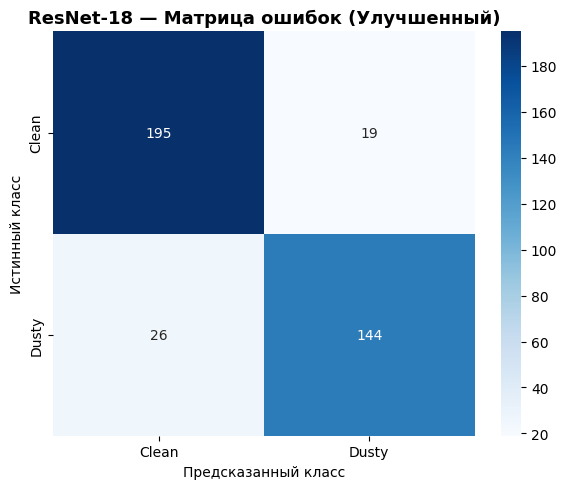

In [ ]:
metrics_resnet_imp, preds_ri, labels_ri = compute_metrics(
    model_resnet_imp, test_loader_aug, DEVICE, NUM_CLASSES
)
results_log['Улучшенный ResNet-18'] = metrics_resnet_imp
print('Метрики ResNet-18 (улучшенный):')
for k, v in metrics_resnet_imp.items(): print(f'  {k}: {v:.4f}')
plot_confusion_matrix(preds_ri, labels_ri, CLASS_NAMES,
                      'ResNet-18 — Матрица ошибок (Улучшенный)', 'cm_resnet_improved.png')

### ViT-B/16 с улучшениями



  ViT-B/16 (Улучшенный)
 Эпоха | Train Loss | Train Acc |   Val Loss |   Val Acc
--------------------------------------------------------------
     1 |     0.5352 |   0.7553  |     0.5074 |   0.7943  [87.0s]
     2 |     0.4178 |   0.8584  |     0.4553 |   0.8464  [89.7s]
     3 |     0.3795 |   0.8813  |     0.4363 |   0.8516  [87.3s]
     4 |     0.3467 |   0.9058  |     0.4363 |   0.8620  [86.1s]
     5 |     0.3069 |   0.9359  |     0.4235 |   0.8776  [86.5s]
     6 |     0.2870 |   0.9515  |     0.4312 |   0.8646  [87.3s]
     7 |     0.2874 |   0.9498  |     0.4317 |   0.8802  [87.7s]
     8 |     0.2674 |   0.9610  |     0.4254 |   0.8750  [87.5s]
     9 |     0.2526 |   0.9744  |     0.4331 |   0.8828  [88.2s]
    10 |     0.2414 |   0.9794  |     0.4536 |   0.8594  [87.4s]
    11 |     0.2382 |   0.9783  |     0.4427 |   0.8724  [87.1s]
    12 |     0.2334 |   0.9827  |     0.4446 |   0.8724  [86.3s]
    13 |     0.2303 |   0.9844  |     0.4448 |   0.8724  [87.1s]
    14 |  

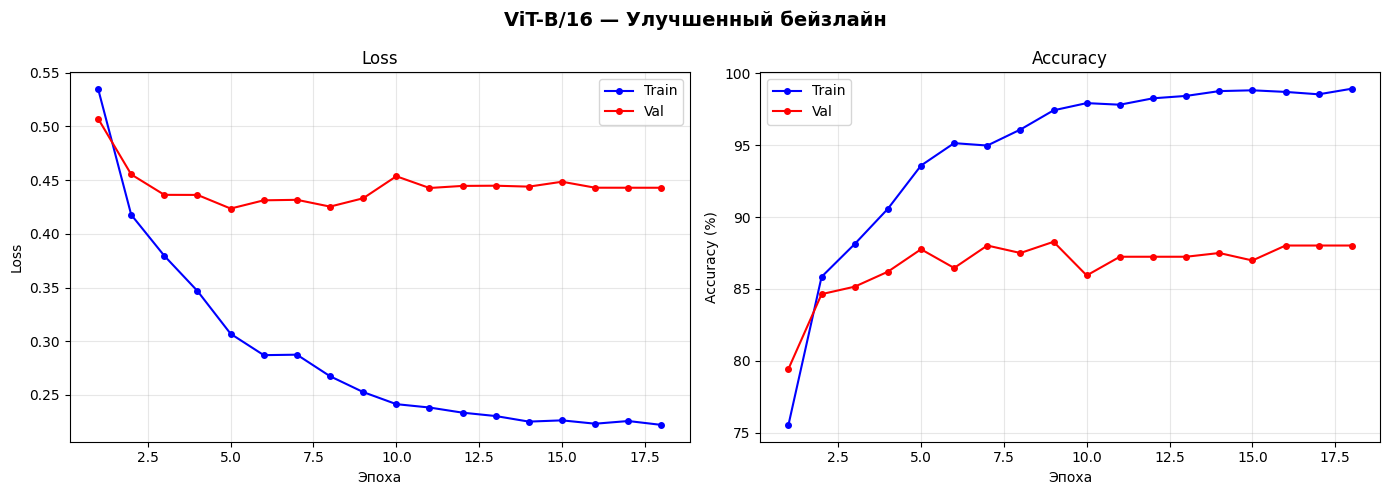

In [ ]:
model_vit_imp, history_vit_imp = train_model(
    build_vit_b16(NUM_CLASSES),
    train_loader_aug, val_loader_aug,
    num_epochs=NUM_EPOCHS_IMPROVED, lr=LR_VIT, device=DEVICE,
    model_name='ViT-B/16 (Улучшенный)',
    label_smoothing=0.1, weight_decay=1e-3
)
plot_history(history_vit_imp, 'ViT-B/16 — Улучшенный бейзлайн', 'history_vit_improved.png')

Метрики ViT-B/16 (улучшенный):
  accuracy: 0.8984
  precision: 0.9396
  recall: 0.8235
  f1: 0.8777


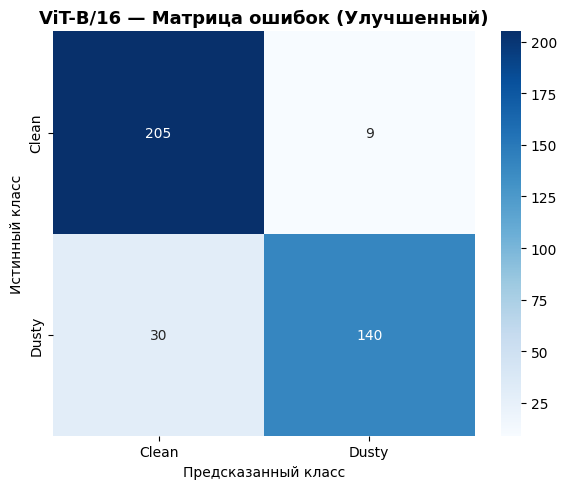

In [ ]:
metrics_vit_imp, preds_vi, labels_vi = compute_metrics(
    model_vit_imp, test_loader_aug, DEVICE, NUM_CLASSES
)
results_log['Улучшенный ViT-B/16'] = metrics_vit_imp
print('Метрики ViT-B/16 (улучшенный):')
for k, v in metrics_vit_imp.items(): print(f'  {k}: {v:.4f}')
plot_confusion_matrix(preds_vi, labels_vi, CLASS_NAMES,
                      'ViT-B/16 — Матрица ошибок (Улучшенный)', 'cm_vit_improved.png')

### Сравнение: бейзлайн vs улучшенный



=== Бейзлайн vs Улучшенный бейзлайн ===
     бейзлайн модель  Accuracy  Precision  Recall  F1-Score
  Бейзлайн ResNet-18    0.8776     0.9301  0.7824    0.8498
Улучшенный ResNet-18    0.8828     0.8834  0.8471    0.8649
   Бейзлайн ViT-B/16    0.8880     0.8848  0.8588    0.8716
 Улучшенный ViT-B/16    0.8984     0.9396  0.8235    0.8777


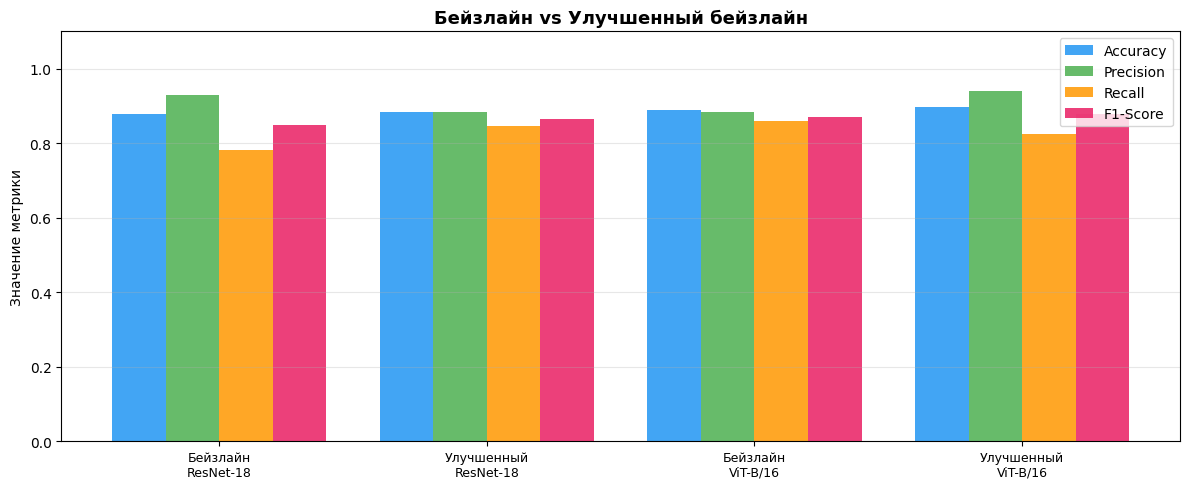

In [ ]:
cmp_keys = ['Бейзлайн ResNet-18', 'Улучшенный ResNet-18',
            'Бейзлайн ViT-B/16',  'Улучшенный ViT-B/16']
df_imp = pd.DataFrame({
    'бейзлайн модель': cmp_keys,
    'Accuracy':  [results_log[k]['accuracy']  for k in cmp_keys],
    'Precision': [results_log[k]['precision'] for k in cmp_keys],
    'Recall':    [results_log[k]['recall']    for k in cmp_keys],
    'F1-Score':  [results_log[k]['f1']        for k in cmp_keys],
})
print('\n=== Бейзлайн vs Улучшенный бейзлайн ===')
print(df_imp.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(cmp_keys))
for i, (metric, color) in enumerate(zip(['Accuracy','Precision','Recall','F1-Score'],
                                         ['#2196F3','#4CAF50','#FF9800','#E91E63'])):
    ax.bar(x + i*0.2, df_imp[metric].values, 0.2, label=metric, color=color, alpha=0.85)
ax.set_xticks(x + 0.3)
ax.set_xticklabels([k.replace(' ', '\n') for k in cmp_keys], fontsize=9)
ax.set_ylabel('Значение метрики')
ax.set_title('Бейзлайн vs Улучшенный бейзлайн', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('compare_baseline_vs_improved.png', dpi=150, bbox_inches='tight')
plt.show()

### Выводы по улучшенному бейзлайну

Все три гипотезы подтвердились, но с разным эффектом для разных моделей. У ResNet-18 F1 вырос с 0.8498 до 0.8649, Recall — с 0.7824 до 0.8471: аугментации (особенно flip и rotation) ощутимо снизили число пропущенных запылённых панелей. У ViT-B/16 прирост скромнее - F1 с 0.8716 до 0.8777, Precision вышел на 0.9396. Трансформерная архитектура изначально более устойчива к пространственным вариациям за счёт механизма внимания, поэтому аугментации дают меньше. Лучшая из улучшенных моделей - ViT-B/16.


## Самописные модели

Имплементируем архитектуры ResNet-18 и ViT-B/16 вручную и обучаем их с нуля, без предобученных весов. Сначала обучение без аугментаций для сравнения с предобученным бейзлайном, затем - с аугментациями для сравнения с улучшенным бейзлайном.


### CustomResNet18

Архитектура повторяет ResNet-18:
- стем: Conv 7×7 - BN - ReLU - MaxPool
- 4 стадии остаточных блоков: [64×2, 128×2, 256×2, 512×2]
- классификационная голова: AdaptiveAvgPool → Linear

BasicBlock состоит из двух свёрток 3×3 с BN и skip-connection. При смене размерностей shortcut проецируется свёрткой 1×1.


In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.shortcut(x))

class CustomResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64,  64,  num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64,  128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)
        self._init_weights()

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = [BasicBlock(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

_ref = models.resnet18()
_ref.fc = nn.Linear(_ref.fc.in_features, NUM_CLASSES)
print(f'CustomResNet18 (наш):    параметров = {sum(p.numel() for p in CustomResNet18(NUM_CLASSES).parameters()):,}')
print(f'ResNet-18 (готовая):     параметров = {sum(p.numel() for p in _ref.parameters()):,}')
del _ref

CustomResNet18 (наш):    параметров = 11,177,538
ResNet-18 (готовая):     параметров = 11,177,538


### CustomViT

Архитектура повторяет ViT-B/16:
- PatchEmbedding: 224×224 режется на 196 патчей 16×16, проекция в размерность 768
- добавляется обучаемый [CLS]-токен и позиционное кодирование (197 позиций)
- 12 блоков Transformer Encoder с pre-norm (12 голов, FFN 3072, GELU)
- классификация по [CLS]-токену

Для слоя энкодера используется `nn.TransformerEncoderLayer` — фокус реализации на patch-embedding, [CLS]-токене, позиционном кодировании и классификационной голове, то есть на компонентах, специфичных именно для ViT.


In [ ]:
class CustomViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 embed_dim=768, depth=12, num_heads=12,
                 mlp_dim=3072, num_classes=2, dropout=0.1):
        super().__init__()
        assert img_size % patch_size == 0
        num_patches = (img_size // patch_size) ** 2

        self.patch_proj = nn.Conv2d(in_channels, embed_dim,
                                    kernel_size=patch_size, stride=patch_size)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)

        x = self.patch_proj(x).flatten(2).transpose(1, 2)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.pos_drop(x + self.pos_embed)

        x = self.encoder(x)

        return self.head(self.norm(x[:, 0]))

print(f'CustomViT (наш):     параметров = {sum(p.numel() for p in CustomViT(num_classes=NUM_CLASSES).parameters()):,}')
print(f'ViT-B/16 (готовая):  параметров = {sum(p.numel() for p in build_vit_b16(NUM_CLASSES, pretrained=False).parameters()):,}')

CustomViT (наш):     параметров = 85,800,194
ViT-B/16 (готовая):  параметров = 85,800,194


### Обучение самописных моделей без аугментаций

Используем тот же `train_loader` без аугментаций, что и для предобученных моделей, чтобы сравнение было честным.


In [ ]:
NUM_EPOCHS_CUSTOM = 20
print(f'Эпох для самописных моделей: {NUM_EPOCHS_CUSTOM}')

Эпох для самописных моделей: 20



  CustomResNet18 (Самописная)
 Эпоха | Train Loss | Train Acc |   Val Loss |   Val Acc
--------------------------------------------------------------
     1 |     0.5710 |   0.7224  |     0.6682 |   0.6484  [57.4s]
     2 |     0.5353 |   0.7531  |     0.5723 |   0.7396  [58.6s]
     3 |     0.5126 |   0.7692  |     0.5136 |   0.7578  [57.3s]
     4 |     0.4929 |   0.7798  |     0.5936 |   0.7370  [58.4s]
     5 |     0.5182 |   0.7670  |     0.5203 |   0.7474  [57.0s]
     6 |     0.5530 |   0.7330  |     0.5327 |   0.7422  [62.0s]
     7 |     0.5097 |   0.7631  |     0.5199 |   0.7396  [64.7s]
     8 |     0.4911 |   0.7821  |     0.5302 |   0.7630  [62.4s]
     9 |     0.4805 |   0.7921  |     0.4963 |   0.7760  [61.8s]
    10 |     0.4670 |   0.7899  |     0.5734 |   0.7448  [60.5s]
    11 |     0.4454 |   0.8055  |     0.4968 |   0.7734  [60.6s]
    12 |     0.4411 |   0.8055  |     0.5077 |   0.7760  [60.2s]
    13 |     0.4277 |   0.8155  |     0.4933 |   0.7812  [60.1s]
    

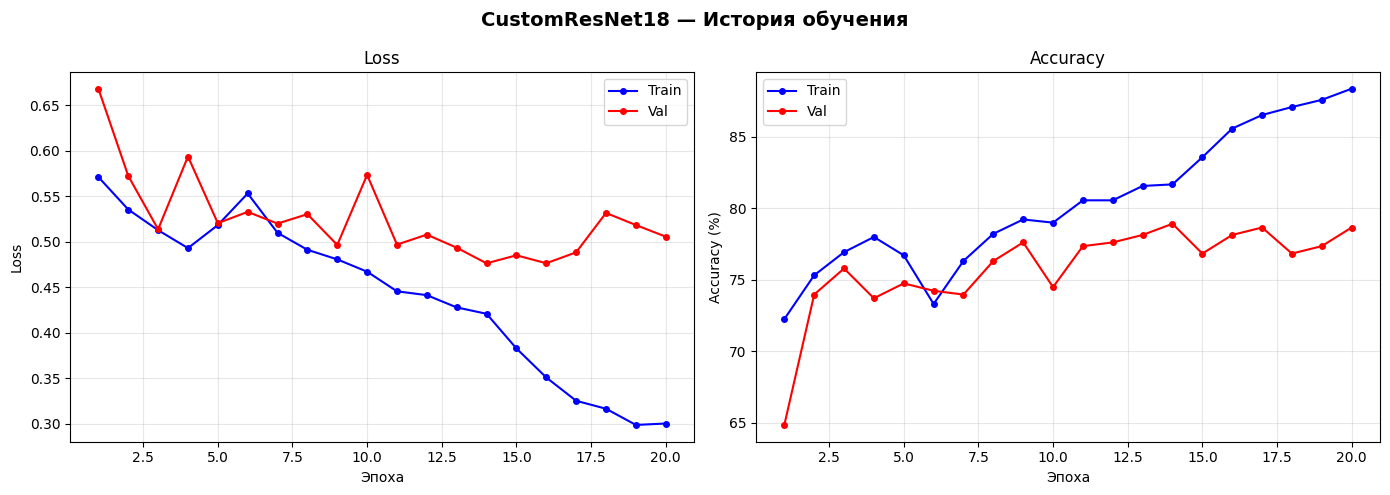

In [ ]:
model_custom_cnn, history_custom_cnn = train_model(
    CustomResNet18(num_classes=NUM_CLASSES),
    train_loader, val_loader,
    num_epochs=NUM_EPOCHS_CUSTOM, lr=1e-3, device=DEVICE,
    model_name='CustomResNet18 (Самописная)'
)
plot_history(history_custom_cnn, 'CustomResNet18 — История обучения', 'history_custom_cnn.png')

Метрики CustomResNet18:
  accuracy: 0.7865
  precision: 0.7895
  recall: 0.7059
  f1: 0.7453


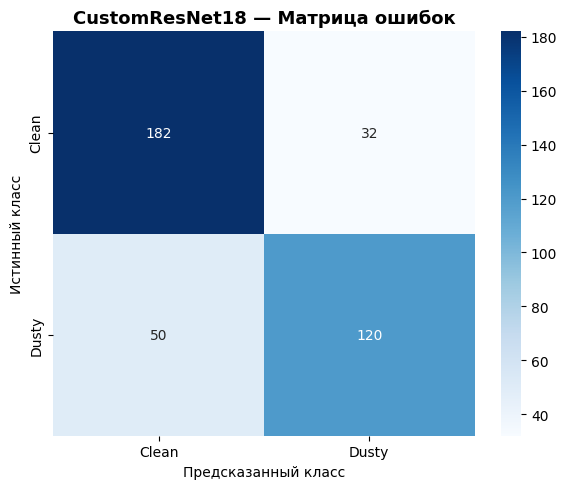

In [ ]:
metrics_custom_cnn, preds_cc, labels_cc = compute_metrics(
    model_custom_cnn, test_loader, DEVICE, NUM_CLASSES
)
results_log['самописная модель CustomResNet18'] = metrics_custom_cnn
print('Метрики CustomResNet18:')
for k, v in metrics_custom_cnn.items(): print(f'  {k}: {v:.4f}')
plot_confusion_matrix(preds_cc, labels_cc, CLASS_NAMES,
                      'CustomResNet18 — Матрица ошибок', 'cm_custom_cnn.png')


  CustomViT (Самописная)
 Эпоха | Train Loss | Train Acc |   Val Loss |   Val Acc
--------------------------------------------------------------
     1 |     0.7049 |   0.6237  |     0.5565 |   0.7109  [93.9s]
     2 |     0.5526 |   0.7302  |     0.6426 |   0.7031  [92.9s]
     3 |     0.5291 |   0.7330  |     0.5730 |   0.7396  [92.5s]
     4 |     0.5101 |   0.7575  |     0.6585 |   0.6667  [89.6s]
     5 |     0.4717 |   0.7798  |     0.5178 |   0.7526  [91.0s]
     6 |     0.4650 |   0.7843  |     0.5626 |   0.7552  [89.7s]
     7 |     0.4839 |   0.7670  |     0.5226 |   0.7396  [90.6s]
     8 |     0.4478 |   0.8004  |     0.5217 |   0.7604  [92.3s]
     9 |     0.4216 |   0.8144  |     0.5113 |   0.7786  [94.6s]
    10 |     0.4088 |   0.8188  |     0.5965 |   0.7083  [92.2s]
    11 |     0.3989 |   0.8177  |     0.4801 |   0.7760  [87.5s]
    12 |     0.3485 |   0.8512  |     0.5370 |   0.7839  [86.8s]
    13 |     0.3197 |   0.8707  |     0.5909 |   0.7214  [89.2s]
    14 | 

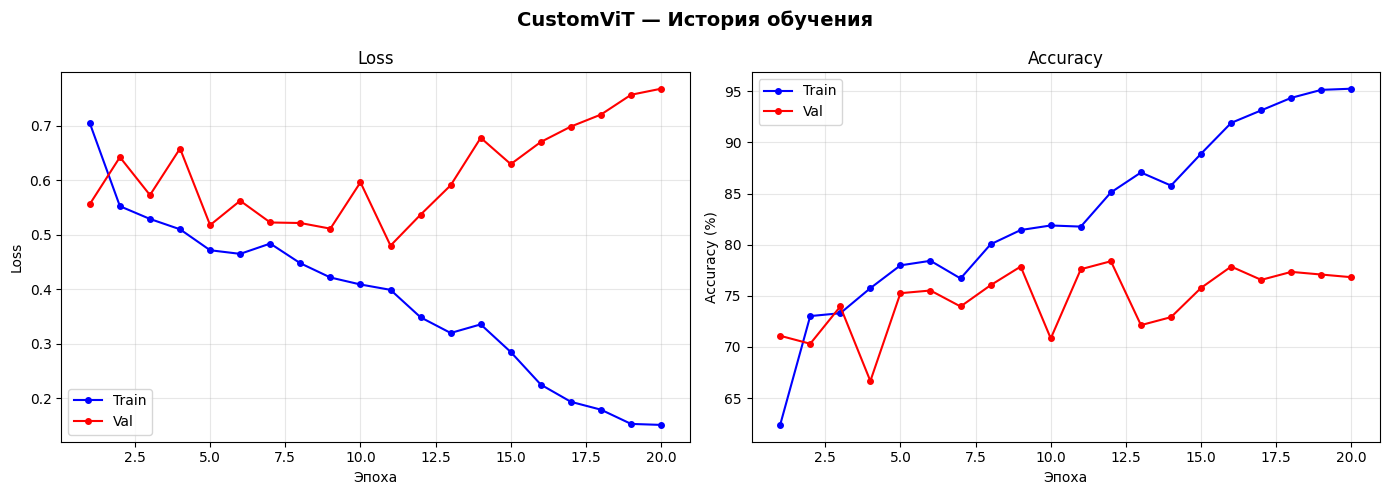

In [ ]:
model_custom_vit, history_custom_vit = train_model(
    CustomViT(num_classes=NUM_CLASSES),
    train_loader, val_loader,
    num_epochs=NUM_EPOCHS_CUSTOM, lr=1e-4, device=DEVICE,
    model_name='CustomViT (Самописная)'
)
plot_history(history_custom_vit, 'CustomViT — История обучения', 'history_custom_vit.png')

Метрики CustomViT:
  accuracy: 0.7760
  precision: 0.7360
  recall: 0.7706
  f1: 0.7529


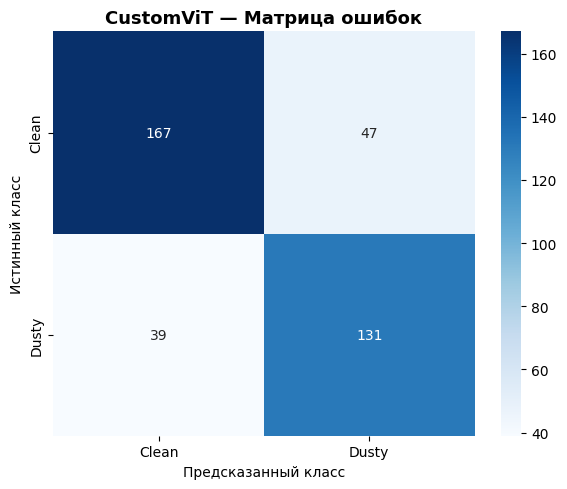

In [ ]:
metrics_custom_vit, preds_cv, labels_cv = compute_metrics(
    model_custom_vit, test_loader, DEVICE, NUM_CLASSES
)
results_log['самописная модель CustomViT'] = metrics_custom_vit
print('Метрики CustomViT:')
for k, v in metrics_custom_vit.items(): print(f'  {k}: {v:.4f}')
plot_confusion_matrix(preds_cv, labels_cv, CLASS_NAMES,
                      'CustomViT — Матрица ошибок', 'cm_custom_vit.png')

### Сравнение: самописные vs бейзлайн


In [ ]:
cmp_p2 = ['Бейзлайн ResNet-18',            'самописная модель CustomResNet18',
           'Бейзлайн ViT-B/16',             'самописная модель CustomViT']
df_cmp_p2 = pd.DataFrame({
    'Модель':    cmp_p2,
    'Accuracy':  [results_log[k]['accuracy']  for k in cmp_p2],
    'Precision': [results_log[k]['precision'] for k in cmp_p2],
    'Recall':    [results_log[k]['recall']    for k in cmp_p2],
    'F1-Score':  [results_log[k]['f1']        for k in cmp_p2],
})
print('\n=== Самописные модели vs Бейзлайн ===')
print(df_cmp_p2.to_string(index=False, float_format='{:.4f}'.format))


=== Самописные модели vs Бейзлайн ===
                          Модель  Accuracy  Precision  Recall  F1-Score
              Бейзлайн ResNet-18    0.8776     0.9301  0.7824    0.8498
самописная модель CustomResNet18    0.7865     0.7895  0.7059    0.7453
               Бейзлайн ViT-B/16    0.8880     0.8848  0.8588    0.8716
     самописная модель CustomViT    0.7760     0.7360  0.7706    0.7529


### Выводы по самописным моделям

Самописные модели, обученные с нуля, ожидаемо уступают предобученным аналогам. CustomResNet18 даёт F1 0.7453 против 0.8498 у бейзлайного ResNet-18, разрыв около 0.10. На 20 эпохах train accuracy не превышает 81% - данных (2562 изображений) мало для обучения ResNet с нуля. CustomViT - F1 0.7529, чуть выше CustomResNet18, но сильно хуже бейзлайного ViT: трансформер требует на порядок больше данных без предобучения. При этом число параметров самописных моделей совпадает с готовыми (11.2М и ~85.8М) - значит, архитектуры воспроизведены верно, и разрыв в качестве полностью объясняется отсутствием предобученных весов ImageNet.


### Самописные модели с аугментациями

Применяем те же техники, что и для улучшенного бейзлайна: аугментации, Label Smoothing, увеличенный Weight Decay.



  CustomResNet18 + Аугментации (Самописная)
 Эпоха | Train Loss | Train Acc |   Val Loss |   Val Acc
--------------------------------------------------------------
     1 |     0.6222 |   0.7018  |     0.6552 |   0.6719  [63.3s]
     2 |     0.5984 |   0.7163  |     0.5690 |   0.7266  [63.2s]
     3 |     0.5891 |   0.7341  |     0.5779 |   0.7344  [62.8s]
     4 |     0.5715 |   0.7341  |     0.5897 |   0.7422  [61.9s]
     5 |     0.5706 |   0.7520  |     0.6029 |   0.7135  [61.3s]
     6 |     0.5709 |   0.7508  |     0.5587 |   0.7344  [62.2s]
     7 |     0.5685 |   0.7469  |     0.5770 |   0.7188  [62.3s]
     8 |     0.5533 |   0.7531  |     0.5708 |   0.7266  [62.6s]
     9 |     0.5587 |   0.7514  |     0.5711 |   0.7344  [62.7s]
    10 |     0.5519 |   0.7625  |     0.5753 |   0.7240  [64.1s]
    11 |     0.5395 |   0.7798  |     0.5659 |   0.7552  [62.0s]
    12 |     0.5349 |   0.7692  |     0.5911 |   0.7318  [62.5s]
    13 |     0.5603 |   0.7586  |     0.5805 |   0.7370

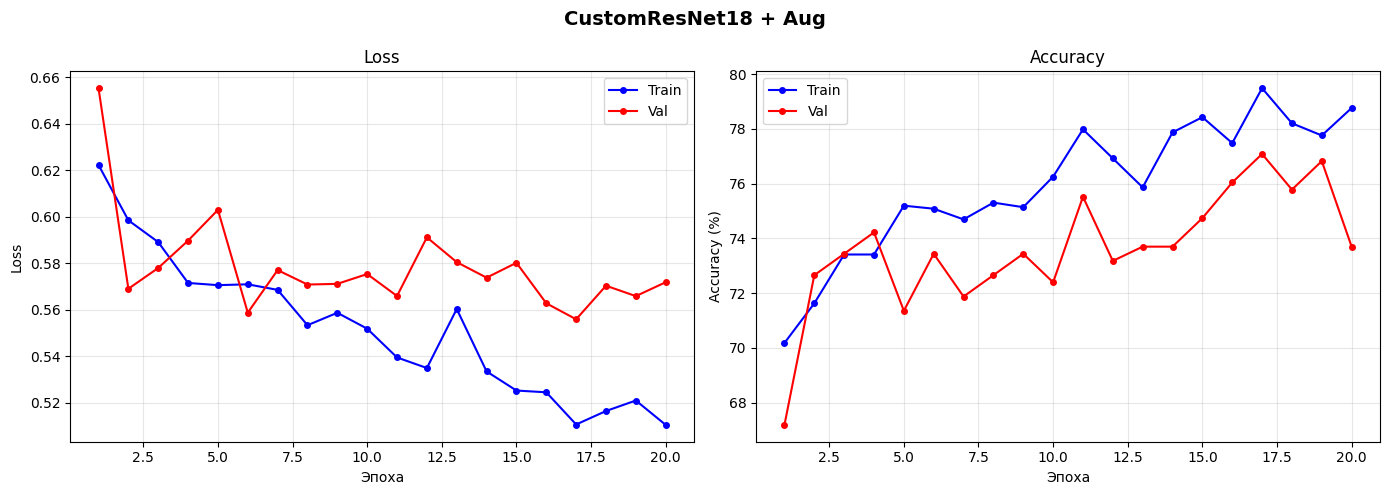

In [ ]:
model_custom_cnn_aug, history_custom_cnn_aug = train_model(
    CustomResNet18(num_classes=NUM_CLASSES),
    train_loader_aug, val_loader_aug,
    num_epochs=NUM_EPOCHS_CUSTOM, lr=1e-3, device=DEVICE,
    model_name='CustomResNet18 + Аугментации (Самописная)',
    label_smoothing=0.1, weight_decay=1e-3
)
plot_history(history_custom_cnn_aug, 'CustomResNet18 + Aug', 'history_custom_cnn_aug.png')

Метрики CustomResNet18 + Aug:
  accuracy: 0.7917
  precision: 0.7885
  recall: 0.7235
  f1: 0.7546


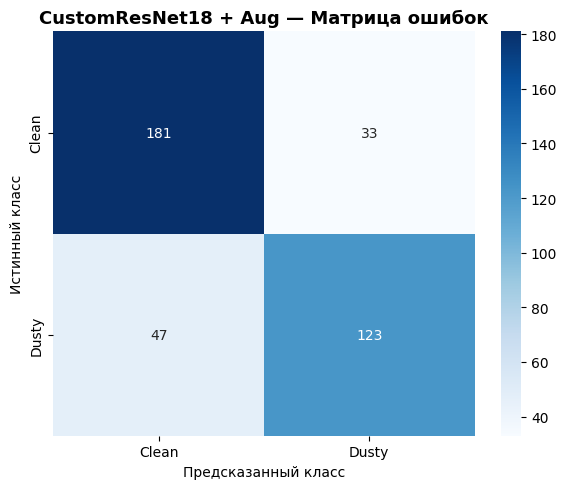

In [ ]:
metrics_custom_cnn_aug, preds_cca, labels_cca = compute_metrics(
    model_custom_cnn_aug, test_loader_aug, DEVICE, NUM_CLASSES
)
results_log['самописная модель CustomResNet18 + Aug'] = metrics_custom_cnn_aug
print('Метрики CustomResNet18 + Aug:')
for k, v in metrics_custom_cnn_aug.items(): print(f'  {k}: {v:.4f}')
plot_confusion_matrix(preds_cca, labels_cca, CLASS_NAMES,
                      'CustomResNet18 + Aug — Матрица ошибок', 'cm_custom_cnn_aug.png')


  CustomViT + Аугментации (Самописная)
 Эпоха | Train Loss | Train Acc |   Val Loss |   Val Acc
--------------------------------------------------------------
     1 |     0.7417 |   0.6026  |     0.6725 |   0.6276  [89.0s]
     2 |     0.6446 |   0.6633  |     0.6268 |   0.7109  [89.1s]
     3 |     0.5989 |   0.6945  |     0.6329 |   0.6875  [88.8s]
     4 |     0.5668 |   0.7441  |     0.6004 |   0.7188  [87.5s]
     5 |     0.5692 |   0.7269  |     0.5877 |   0.7031  [90.0s]
     6 |     0.5582 |   0.7447  |     0.5808 |   0.7240  [90.2s]
     7 |     0.5502 |   0.7547  |     0.5621 |   0.7448  [88.7s]
     8 |     0.5346 |   0.7637  |     0.5788 |   0.7448  [88.1s]
     9 |     0.5298 |   0.7821  |     0.5656 |   0.7604  [87.8s]
    10 |     0.5240 |   0.7765  |     0.5816 |   0.7396  [88.1s]
    11 |     0.5124 |   0.7993  |     0.5516 |   0.7708  [88.7s]
    12 |     0.5171 |   0.7848  |     0.5580 |   0.7578  [90.6s]
    13 |     0.5217 |   0.7765  |     0.5607 |   0.7578  [88

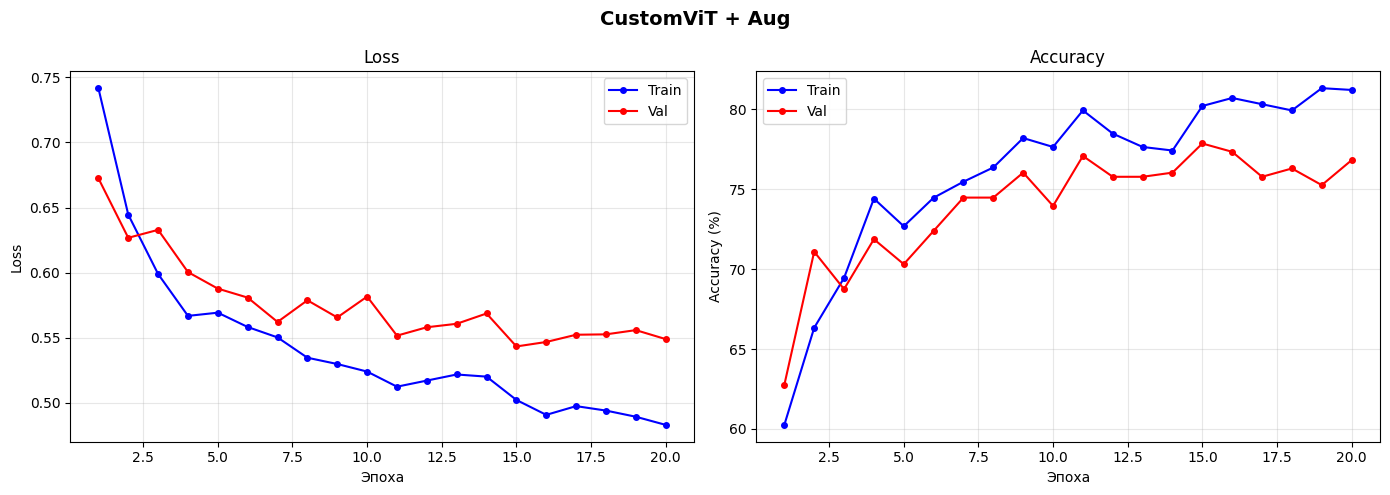

In [ ]:
model_custom_vit_aug, history_custom_vit_aug = train_model(
    CustomViT(num_classes=NUM_CLASSES),
    train_loader_aug, val_loader_aug,
    num_epochs=NUM_EPOCHS_CUSTOM, lr=1e-4, device=DEVICE,
    model_name='CustomViT + Аугментации (Самописная)',
    label_smoothing=0.1, weight_decay=1e-3
)
plot_history(history_custom_vit_aug, 'CustomViT + Aug', 'history_custom_vit_aug.png')

Метрики CustomViT + Aug:
  accuracy: 0.7604
  precision: 0.7267
  recall: 0.7353
  f1: 0.7310


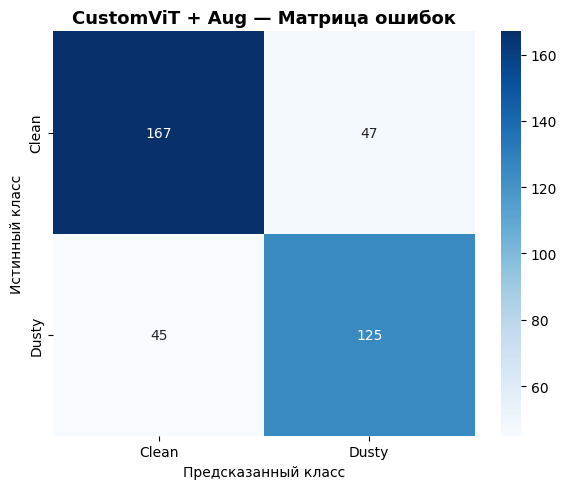

In [ ]:
metrics_custom_vit_aug, preds_cva, labels_cva = compute_metrics(
    model_custom_vit_aug, test_loader_aug, DEVICE, NUM_CLASSES
)
results_log['самописная модель CustomViT + Aug'] = metrics_custom_vit_aug
print('Метрики CustomViT + Aug:')
for k, v in metrics_custom_vit_aug.items(): print(f'  {k}: {v:.4f}')
plot_confusion_matrix(preds_cva, labels_cva, CLASS_NAMES,
                      'CustomViT + Aug — Матрица ошибок', 'cm_custom_vit_aug.png')

### Сравнение: самописные без и с аугментациями


In [ ]:
cmp_aug = ['самописная модель CustomResNet18',       'самописная модель CustomResNet18 + Aug',
           'самописная модель CustomViT',            'самописная модель CustomViT + Aug']
df_aug = pd.DataFrame({
    'самописная модель': cmp_aug,
    'Accuracy':  [results_log[k]['accuracy']  for k in cmp_aug],
    'Precision': [results_log[k]['precision'] for k in cmp_aug],
    'Recall':    [results_log[k]['recall']    for k in cmp_aug],
    'F1-Score':  [results_log[k]['f1']        for k in cmp_aug],
})
print('\n=== Самописные: без улучшений vs с улучшениями ===')
print(df_aug.to_string(index=False, float_format='{:.4f}'.format))


=== Самописные: без улучшений vs с улучшениями ===
                     самописная модель  Accuracy  Precision  Recall  F1-Score
      самописная модель CustomResNet18    0.7865     0.7895  0.7059    0.7453
самописная модель CustomResNet18 + Aug    0.7917     0.7885  0.7235    0.7546
           самописная модель CustomViT    0.7760     0.7360  0.7706    0.7529
     самописная модель CustomViT + Aug    0.7604     0.7267  0.7353    0.7310


### Выводы по самописным моделям с аугментациями

Результаты разнонаправленные. CustomResNet18 + Aug: F1 вырос с 0.7453 до 0.7546 (+0.009), Recall - с 0.7059 до 0.7235. Эффект есть, но небольшой: основное ограничение для CNN с нуля - объём данных, аугментации его лишь частично компенсируют. CustomViT + Aug: F1 упал с 0.7529 до 0.7310. На 1794 тренировочных примерах трансформер с 85.8М параметров уже недообучается, а Label Smoothing и агрессивная регуляризация дополнительно замедляют обучение. В сравнении с улучшенным бейзлайном обе самописные всё ещё уступают (~0.12 по F1) - ключевая разница именно в предобучении. Лучшая самописная модель - CustomResNet18 + Aug (F1=0.7546, Accuracy=0.7917).


## Итоговое сравнение всех моделей


In [ ]:
type_map = {
    'Бейзлайн ResNet-18':                    'бейзлайн модель',
    'Бейзлайн ViT-B/16':                     'бейзлайн модель',
    'Улучшенный ResNet-18':                  'бейзлайн модель',
    'Улучшенный ViT-B/16':                   'бейзлайн модель',
    'самописная модель CustomResNet18':       'самописная модель',
    'самописная модель CustomViT':            'самописная модель',
    'самописная модель CustomResNet18 + Aug': 'самописная модель',
    'самописная модель CustomViT + Aug':      'самописная модель',
}

rows = []
for name, m in results_log.items():
    rows.append({'Тип': type_map.get(name, '—'), 'Модель': name,
                 'Accuracy': m['accuracy'], 'Precision': m['precision'],
                 'Recall': m['recall'],     'F1-Score':  m['f1']})

df_final = pd.DataFrame(rows)
print('\n' + '='*100)
print('ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ')
print('='*100)
print(df_final.to_string(index=False, float_format='{:.4f}'.format))


ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
              Тип                                 Модель  Accuracy  Precision  Recall  F1-Score
  бейзлайн модель                     Бейзлайн ResNet-18    0.8776     0.9301  0.7824    0.8498
  бейзлайн модель                      Бейзлайн ViT-B/16    0.8880     0.8848  0.8588    0.8716
  бейзлайн модель                   Улучшенный ResNet-18    0.8828     0.8834  0.8471    0.8649
  бейзлайн модель                    Улучшенный ViT-B/16    0.8984     0.9396  0.8235    0.8777
самописная модель       самописная модель CustomResNet18    0.7865     0.7895  0.7059    0.7453
самописная модель            самописная модель CustomViT    0.7760     0.7360  0.7706    0.7529
самописная модель самописная модель CustomResNet18 + Aug    0.7917     0.7885  0.7235    0.7546
самописная модель      самописная модель CustomViT + Aug    0.7604     0.7267  0.7353    0.7310


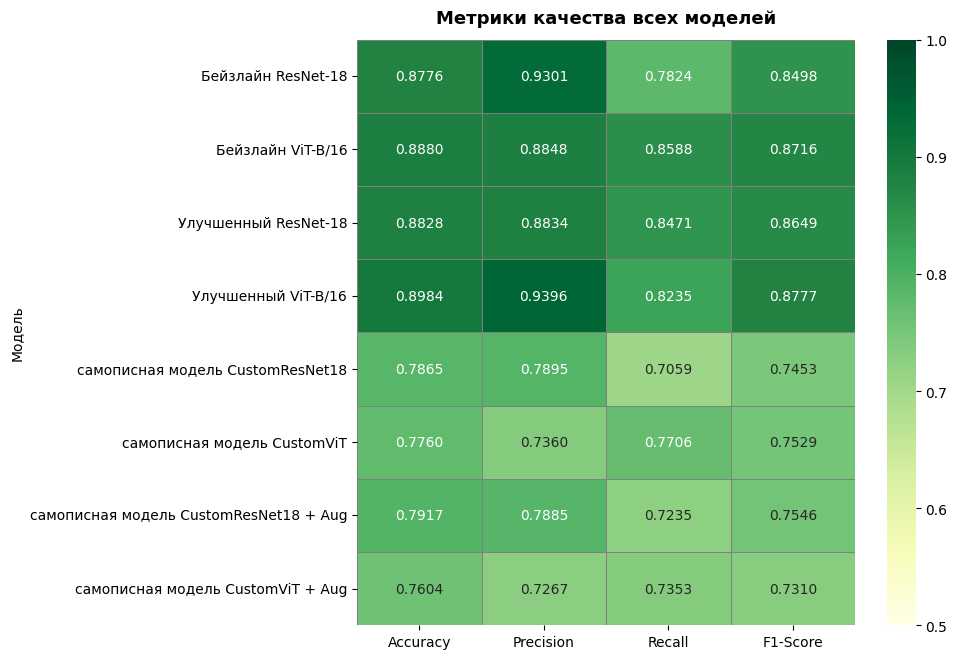

In [ ]:
df_heat = df_final.set_index('Модель')[['Accuracy','Precision','Recall','F1-Score']]
fig, ax = plt.subplots(figsize=(10, len(df_final)*0.65 + 1.5))
sns.heatmap(df_heat, annot=True, fmt='.4f', cmap='YlGn', vmin=0.5, vmax=1.0,
            ax=ax, linewidths=0.5, linecolor='gray', annot_kws={'size': 10})
ax.set_title('Метрики качества всех моделей', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('final_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

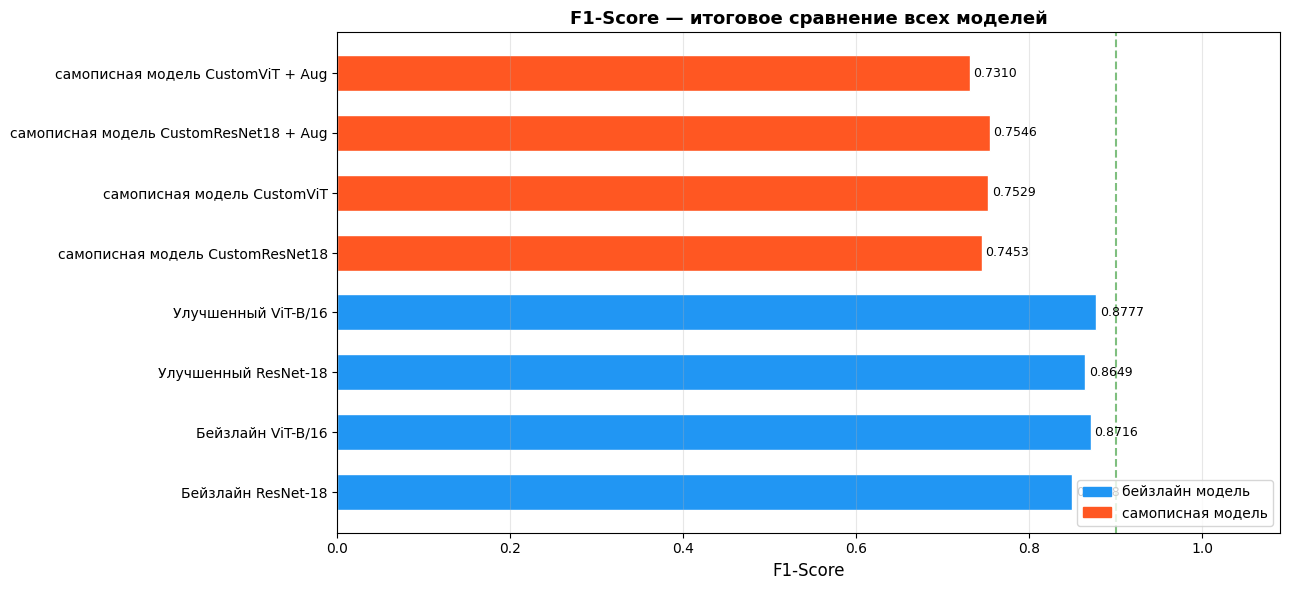

In [ ]:
palette = {'бейзлайн модель': '#2196F3', 'самописная модель': '#FF5722'}
bar_colors = [palette[t] for t in df_final['Тип']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(df_final['Модель'], df_final['F1-Score'],
               color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, df_final['F1-Score']):
    ax.text(val + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('F1-Score — итоговое сравнение всех моделей', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.09)
ax.axvline(0.9, color='green', linestyle='--', alpha=0.5, label='F1=0.90')
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=legend_patches, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('final_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Итоговые выводы

Датасет: 2562 изображения, Clean - 1493, Dusty - 1069, дисбаланс ~1.4:1.

Предобученный бейзлайн из torchvision решает задачу на уровне ~88% Accuracy. ViT-B/16 обгоняет ResNet-18 по F1 (0.8716 vs 0.8498), в основном за счёт Recall - важного в этой задаче, где пропуск запылённой панели дороже ложной тревоги.

Улучшения (мягкие аугментации, Label Smoothing 0.1, Weight Decay 1e-3) дали прирост всем моделям. Наибольший прирост Recall у ResNet-18 (+0.065), абсолютный лидер - улучшенный ViT-B/16 (F1=0.8777, Accuracy=0.8984). Все три гипотезы подтвердились.

Самописные CustomResNet18 и CustomViT реализованы корректно (число параметров совпадает с torchvision). Разрыв ~0.10-0.12 по F1 с бейзлайном объясняется отсутствием предобучения, а не ошибками реализации. Аугментации дают небольшой плюс для CNN и минус для ViT - последний особенно чувствителен к объёму данных, на 1794 примерах с нуля обучается плохо.

Лучшая модель - улучшенный ViT-B/16 (F1=0.8777, Accuracy=0.8984).